In [1]:
from google.colab import files
uploaded=files.upload()

Saving student_performance_dataset.csv to student_performance_dataset.csv


In [2]:
import pandas as pd
import numpy as np



In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

In [5]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

In [7]:
df = pd.read_csv("student_performance_dataset.csv")

In [8]:
print("Dataset Shape:", df.shape)
print("\nFirst 5 Rows")
print(df.head())

Dataset Shape: (708, 10)

First 5 Rows
  Student_ID  Gender  Study_Hours_per_Week  Attendance_Rate  Past_Exam_Scores  \
0       S147    Male                    31        68.267841                86   
1       S136    Male                    16        78.222927                73   
2       S209  Female                    21        87.525096                74   
3       S458  Female                    27        92.076483                99   
4       S078  Female                    37        98.655517                63   

  Parental_Education_Level Internet_Access_at_Home Extracurricular_Activities  \
0              High School                     Yes                        Yes   
1                      PhD                      No                         No   
2                      PhD                     Yes                         No   
3                Bachelors                      No                         No   
4                  Masters                      No                   

In [9]:
print("\nMissing Values")
print(df.isnull().sum())


Missing Values
Student_ID                    0
Gender                        0
Study_Hours_per_Week          0
Attendance_Rate               0
Past_Exam_Scores              0
Parental_Education_Level      0
Internet_Access_at_Home       0
Extracurricular_Activities    0
Final_Exam_Score              0
Pass_Fail                     0
dtype: int64


In [10]:
df.drop_duplicates(inplace=True)


In [11]:

print("\nDataset Shape After Removing Duplicates")
print(df.shape)




Dataset Shape After Removing Duplicates
(500, 10)


In [12]:
print("\n===== DESCRIPTIVE STATISTICS =====")


===== DESCRIPTIVE STATISTICS =====


In [13]:

print("Average Study Hours:",
      df["Study_Hours_per_Week"].mean())

Average Study Hours: 25.184


In [14]:
print("Average Attendance:",
      df["Attendance_Rate"].mean())


Average Attendance: 75.83068883324734


In [15]:
print("Average Past Exam Score:",
      df["Past_Exam_Scores"].mean())


Average Past Exam Score: 75.218


In [16]:
print("Average Final Exam Score:",
      df["Final_Exam_Score"].mean())

Average Final Exam Score: 56.378


In [17]:
print("\nPass / Fail Count")
print(df["Pass_Fail"].value_counts())


Pass / Fail Count
Pass_Fail
Fail    354
Pass    146
Name: count, dtype: int64


In [18]:
print("\nGender Distribution")
print(df["Gender"].value_counts())


Gender Distribution
Gender
Female    256
Male      244
Name: count, dtype: int64


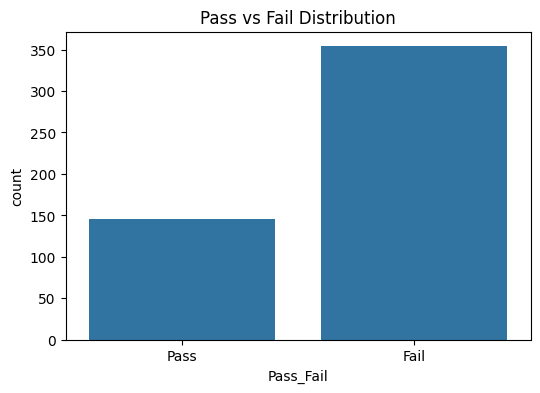

In [19]:
plt.figure(figsize=(6,4))
sns.countplot(x="Pass_Fail", data=df)
plt.title("Pass vs Fail Distribution")
plt.show()

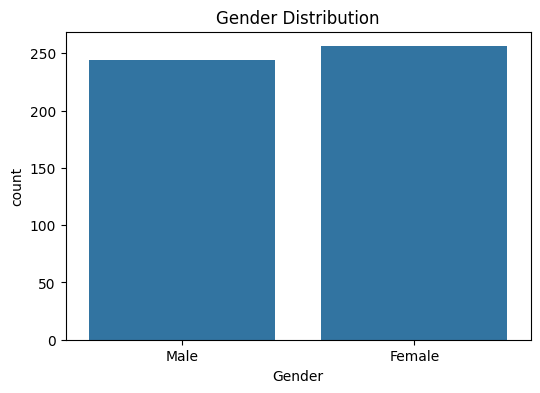

In [20]:
plt.figure(figsize=(6,4))
sns.countplot(x="Gender", data=df)
plt.title("Gender Distribution")
plt.show()

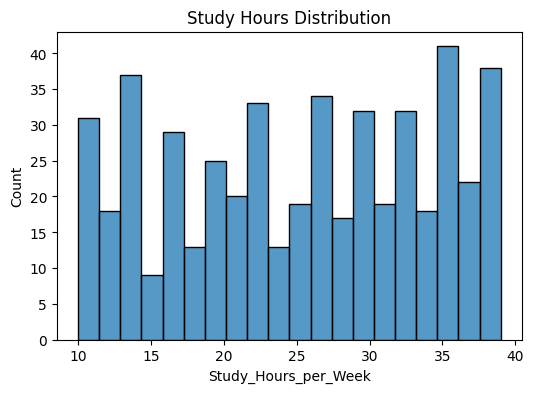

In [21]:
plt.figure(figsize=(6,4))
sns.histplot(df["Study_Hours_per_Week"], bins=20)
plt.title("Study Hours Distribution")
plt.show()

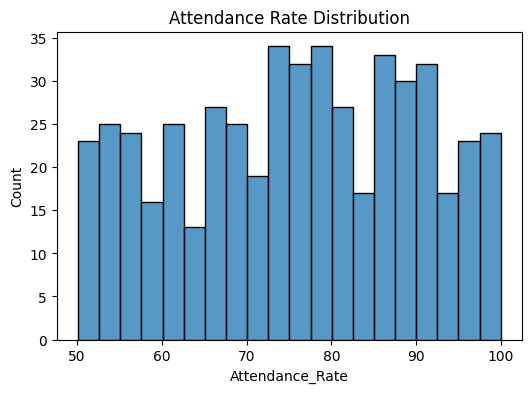

In [22]:
plt.figure(figsize=(6,4))
sns.histplot(df["Attendance_Rate"], bins=20)
plt.title("Attendance Rate Distribution")
plt.show()


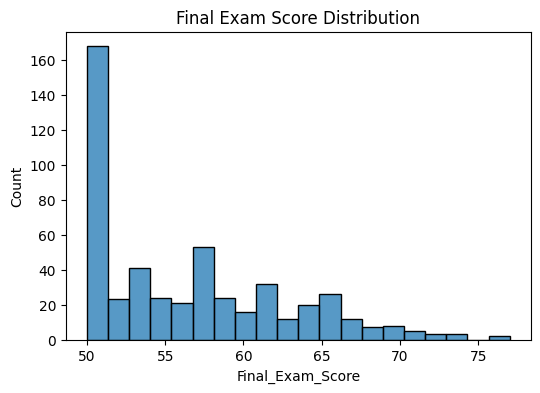

In [23]:
plt.figure(figsize=(6,4))
sns.histplot(df["Final_Exam_Score"], bins=20)
plt.title("Final Exam Score Distribution")
plt.show()

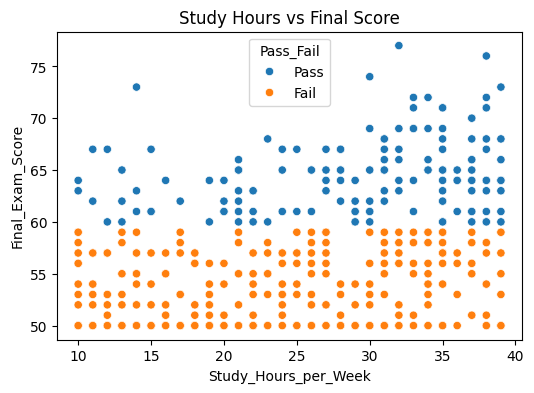

In [24]:
plt.figure(figsize=(6,4))
sns.scatterplot(
    x="Study_Hours_per_Week",
    y="Final_Exam_Score",
    hue="Pass_Fail",
    data=df
)
plt.title("Study Hours vs Final Score")
plt.show()

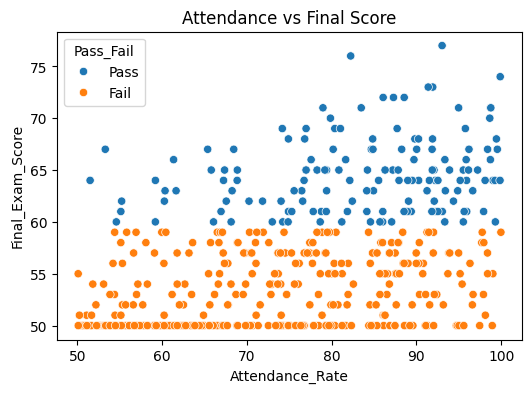

In [25]:
plt.figure(figsize=(6,4))
sns.scatterplot(
    x="Attendance_Rate",
    y="Final_Exam_Score",
    hue="Pass_Fail",
    data=df
)
plt.title("Attendance vs Final Score")
plt.show()

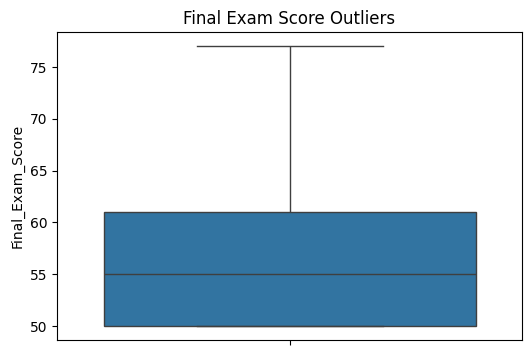

In [26]:
plt.figure(figsize=(6,4))
sns.boxplot(y=df["Final_Exam_Score"])
plt.title("Final Exam Score Outliers")
plt.show()


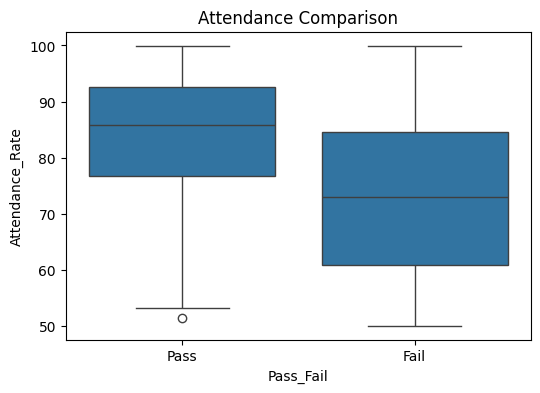

In [27]:
plt.figure(figsize=(6,4))
sns.boxplot(
    x="Pass_Fail",
    y="Attendance_Rate",
    data=df
)
plt.title("Attendance Comparison")
plt.show()

In [28]:
encoder = LabelEncoder()

In [29]:
categorical_cols = [
    "Gender",
    "Parental_Education_Level",
    "Internet_Access_at_Home",
    "Extracurricular_Activities",
    "Pass_Fail"
]

In [30]:
for col in categorical_cols:
    df[col] = encoder.fit_transform(df[col])

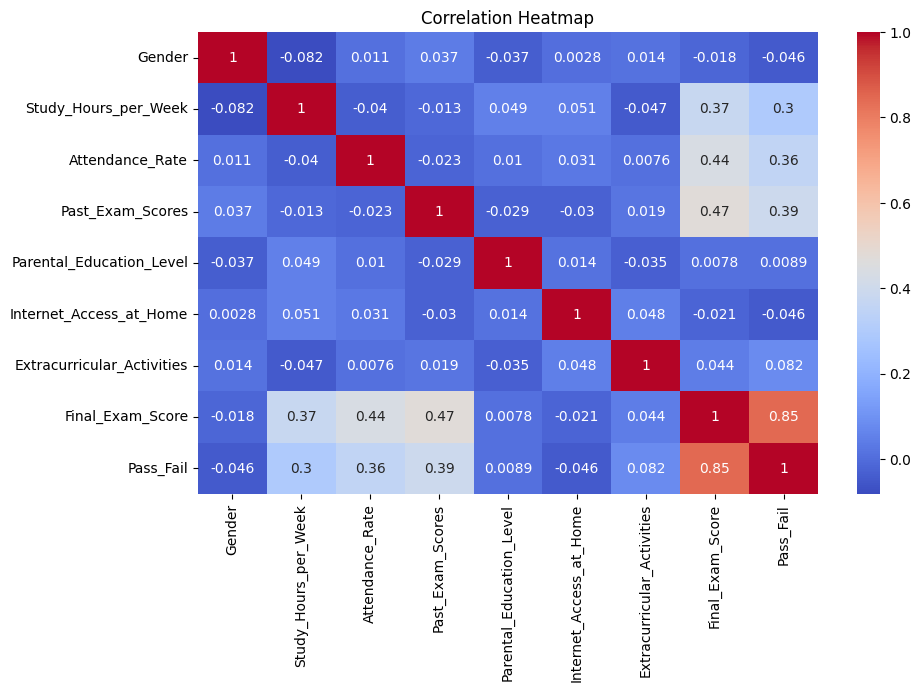

In [34]:
plt.figure(figsize=(10,6))

numeric_df = df.select_dtypes(include=['int64','float64'])

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()


In [36]:
def risk_category(row):

    if (
        row["Attendance_Rate"] < 60 and
        row["Study_Hours_per_Week"] < 10 and
        row["Past_Exam_Scores"] < 50
    ):
        return "High Risk"

    elif (
        row["Attendance_Rate"] < 80 and
        row["Past_Exam_Scores"] < 70
    ):
        return "Medium Risk"

    else:
        return "Low Risk"

In [37]:
df["Risk_Category"] = df.apply(risk_category, axis=1)

In [38]:
print("\nRisk Category Count")
print(df["Risk_Category"].value_counts())


Risk Category Count
Risk_Category
Low Risk       391
Medium Risk    109
Name: count, dtype: int64


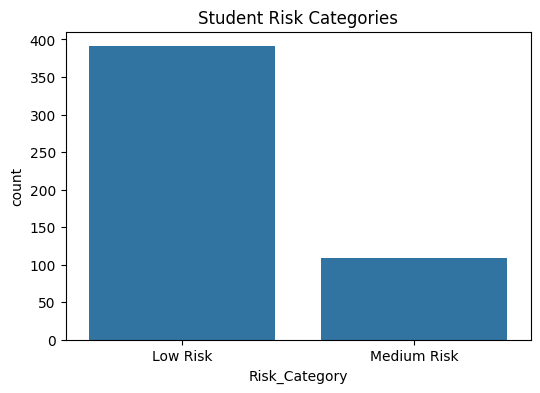

In [39]:
plt.figure(figsize=(6,4))
sns.countplot(
    x="Risk_Category",
    data=df
)
plt.title("Student Risk Categories")
plt.show()

In [40]:
if "Student_ID" in df.columns:
    df.drop("Student_ID", axis=1, inplace=True)

In [41]:
X = df.drop(
    ["Pass_Fail", "Risk_Category"],
    axis=1
)

In [42]:
y = df["Pass_Fail"]

In [43]:
scaler = StandardScaler()

In [44]:
X_scaled = scaler.fit_transform(X)

In [45]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)


In [46]:
model = LogisticRegression(max_iter=1000)

In [47]:
model.fit(X_train, y_train)


LogisticRegression(max_iter=1000)

In [48]:
y_pred = model.predict(X_test)

In [49]:
y_prob = model.predict_proba(X_test)[:,1]

In [50]:
print("\n===== MODEL PERFORMANCE =====")


===== MODEL PERFORMANCE =====


In [51]:
print("Accuracy:",
      accuracy_score(y_test, y_pred))

Accuracy: 0.98


In [52]:
print("Precision:",
      precision_score(y_test, y_pred))

Precision: 1.0


In [53]:
print("Recall:",
      recall_score(y_test, y_pred))

Recall: 0.92


In [54]:
print("F1 Score:",
      f1_score(y_test, y_pred))

F1 Score: 0.9583333333333334


In [55]:
print("ROC AUC Score:",
      roc_auc_score(y_test, y_prob))

ROC AUC Score: 0.9994666666666667


In [56]:
print("\nConfusion Matrix")
cm = confusion_matrix(y_test, y_pred)
print(cm)


Confusion Matrix
[[75  0]
 [ 2 23]]


In [57]:
print("\nClassification Report")
print(classification_report(y_test, y_pred))


Classification Report
              precision    recall  f1-score   support

           0       0.97      1.00      0.99        75
           1       1.00      0.92      0.96        25

    accuracy                           0.98       100
   macro avg       0.99      0.96      0.97       100
weighted avg       0.98      0.98      0.98       100



<Axes: >

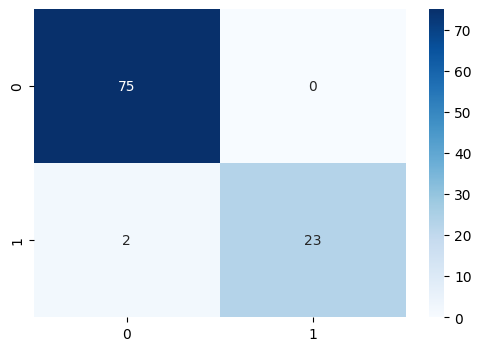

In [58]:
plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

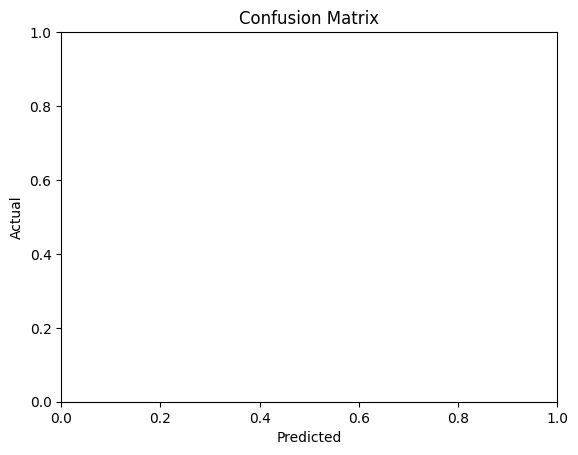

In [59]:
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [60]:
df.to_csv(
    "student_performance_cleaned.csv",
    index=False
)

In [61]:

print("\nProject Completed Successfully")


Project Completed Successfully
